In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from google.colab import files

uploaded = files.upload()

Saving student-mat.csv to student-mat.csv


In [ ]:
df = pd.read_csv("data/student-mat.csv", sep=";")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

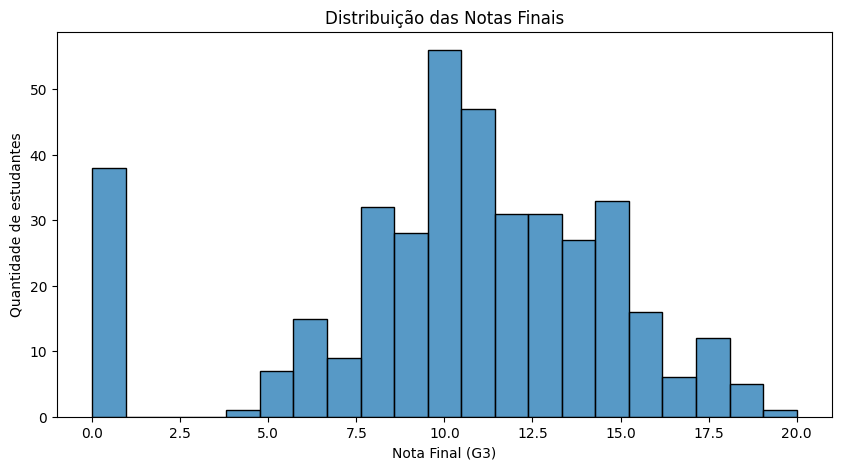

,proportion
resultado,
Aprovado,67.088608
Reprovado,32.911392


In [9]:
df.head()
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()
df["G3"].value_counts().sort_index()
df["G3"].describe()
plt.figure(figsize=(10, 5))

sns.histplot(df["G3"], bins=21)

plt.title("Distribuição das Notas Finais")
plt.xlabel("Nota Final (G3)")
plt.ylabel("Quantidade de estudantes")

plt.show()

df["resultado"] = np.where(df["G3"] >= 10, "Aprovado", "Reprovado")
df[["G3", "resultado"]].head(20)

df["resultado"].value_counts()
df["resultado"].value_counts(normalize=True) * 100

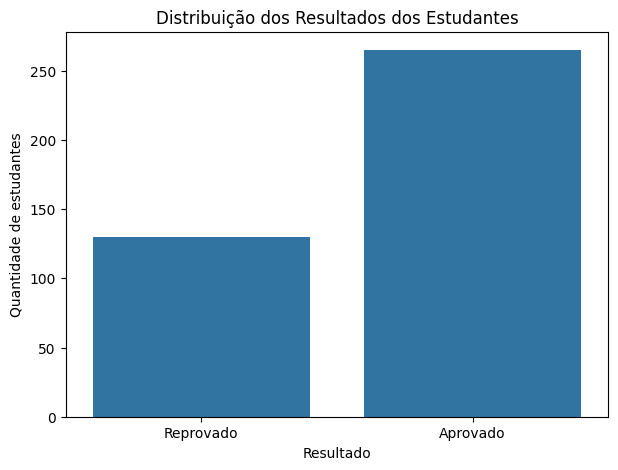

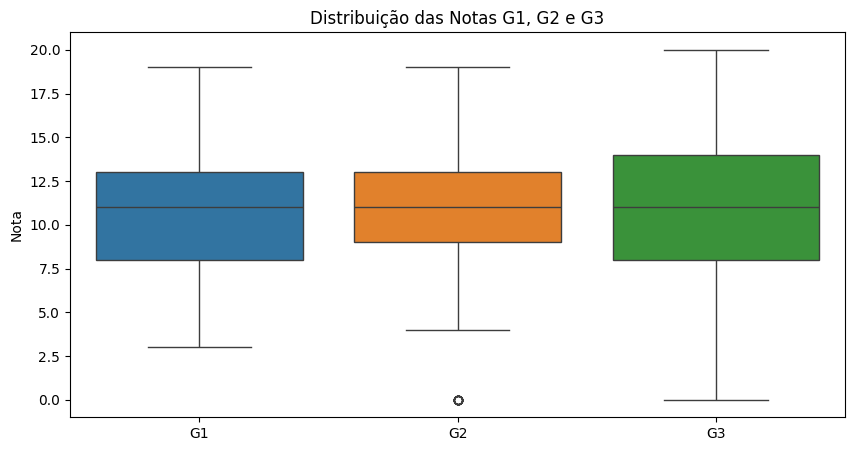

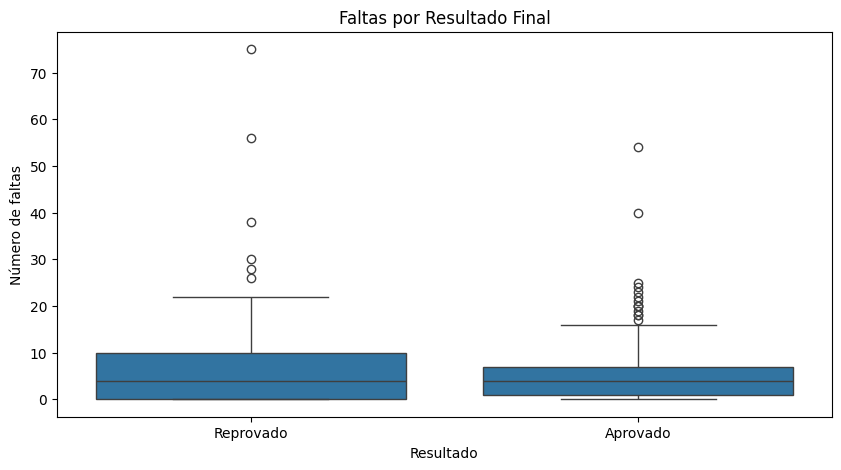

In [10]:
df.duplicated().sum()
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="resultado")

plt.title("Distribuição dos Resultados dos Estudantes")
plt.xlabel("Resultado")
plt.ylabel("Quantidade de estudantes")

plt.show()
df[["G1", "G2", "G3"]].describe()
plt.figure(figsize=(10, 5))

sns.boxplot(data=df[["G1", "G2", "G3"]])

plt.title("Distribuição das Notas G1, G2 e G3")
plt.ylabel("Nota")

plt.show()
pd.crosstab(df["resultado"], df["G1"])
pd.crosstab(df["resultado"], df["G2"])


plt.figure(figsize=(10, 5))

sns.boxplot(data=df, x="resultado", y="absences")

plt.title("Faltas por Resultado Final")
plt.xlabel("Resultado")
plt.ylabel("Número de faltas")

plt.show()

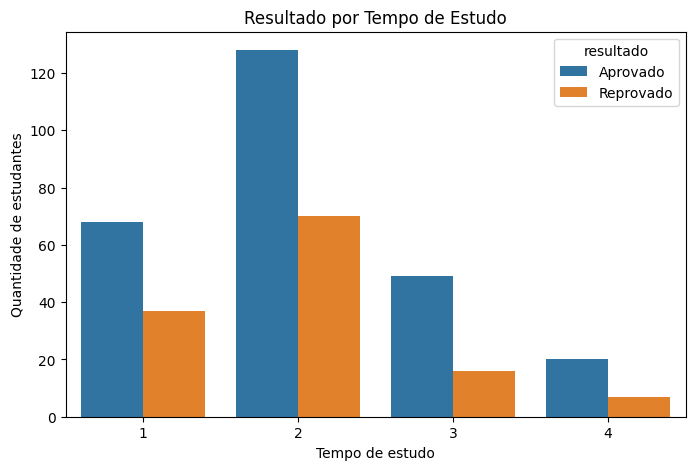

In [11]:
#tempo de estudo
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="studytime", hue="resultado")

plt.title("Resultado por Tempo de Estudo")
plt.xlabel("Tempo de estudo")
plt.ylabel("Quantidade de estudantes")

plt.show()

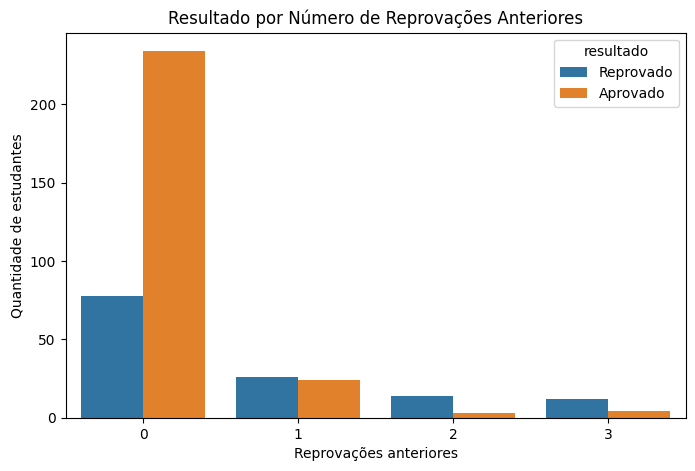

In [12]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="failures", hue="resultado")

plt.title("Resultado por Número de Reprovações Anteriores")
plt.xlabel("Reprovações anteriores")
plt.ylabel("Quantidade de estudantes")

plt.show()

In [13]:
df[df["G3"] == 0][
    ["G1", "G2", "G3", "absences", "failures"]
]
print("Quantidade de G3 igual a 0:", (df["G3"] == 0).sum())
df[df["G3"] == 0][
    ["G1", "G2", "absences", "failures"]
].describe()

Quantidade de G3 igual a 0: 38


,G1,G2,absences,failures
count,38.000000,38.000000,38.0,38.000000
mean,7.526316,4.657895,0.0,0.921053
std,1.811925,3.700083,0.0,1.075063
min,4.000000,0.000000,0.0,0.000000
25%,6.000000,0.000000,0.0,0.000000
50%,7.000000,5.000000,0.0,1.000000
75%,9.000000,8.000000,0.0,1.750000
max,12.000000,10.000000,0.0,3.000000


In [14]:
X = df.drop(columns=["G1", "G2", "G3", "resultado"])
y = df["resultado"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Dataset completo:", X.shape)
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

print("\nTreino:")
print(y_train.value_counts())

print("\nTeste:")
print(y_test.value_counts())

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

colunas_categoricas = X.select_dtypes(include=["object"]).columns
colunas_numericas = X.select_dtypes(include=["int64", "float64"]).columns

print("Categóricas:")
print(list(colunas_categoricas))

print("\nNuméricas:")
print(list(colunas_numericas))
preprocessador = ColumnTransformer(
    transformers=[
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            colunas_categoricas
        ),
        (
            "numericas",
            StandardScaler(),
            colunas_numericas
        )
    ]
)

Dataset completo: (395, 30)
Treino: (316, 30)
Teste: (79, 30)

Treino:
resultado
Aprovado     212
Reprovado    104
Name: count, dtype: int64

Teste:
resultado
Aprovado     53
Reprovado    26
Name: count, dtype: int64
Categóricas:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numéricas:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


Acurácia: 0.6962025316455697
              precision    recall  f1-score   support

    Aprovado       0.72      0.89      0.80        53
   Reprovado       0.57      0.31      0.40        26

    accuracy                           0.70        79
   macro avg       0.65      0.60      0.60        79
weighted avg       0.67      0.70      0.67        79



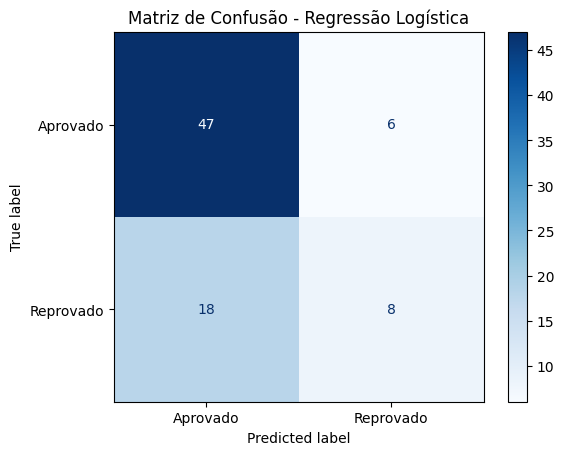

In [28]:
X
y

X_train
X_test
y_train
y_test

preprocessador

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

modelo_logistico = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", LogisticRegression(max_iter=1000))
])

modelo_logistico.fit(X_train, y_train)

y_pred = modelo_logistico.predict(X_test)

comparacao = pd.DataFrame({
    "Real": y_test,
    "Previsto": y_pred
})

comparacao.head(15)

from sklearn.metrics import accuracy_score

acuracia = accuracy_score(y_test, y_pred)

print("Acurácia:", acuracia)

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Matriz de Confusão - Regressão Logística")
plt.show()

Acurácia Random Forest: 70.89%

Relatório de Classificação:
              precision    recall  f1-score   support

    Aprovado       0.73      0.91      0.81        53
   Reprovado       0.62      0.31      0.41        26

    accuracy                           0.71        79
   macro avg       0.67      0.61      0.61        79
weighted avg       0.69      0.71      0.68        79



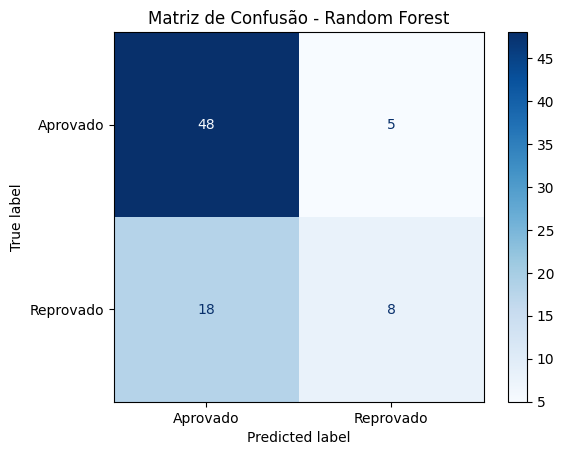

In [36]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

acuracia_rf = accuracy_score(y_test, y_pred_rf)

print(f"Acurácia Random Forest: {acuracia_rf * 100:.2f}%")

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues"
)

plt.title("Matriz de Confusão - Random Forest")
plt.show()


Acurácia Random Forest Balanceado: 68.35%

Relatório de Classificação:
              precision    recall  f1-score   support

    Aprovado       0.70      0.92      0.80        53
   Reprovado       0.56      0.19      0.29        26

    accuracy                           0.68        79
   macro avg       0.63      0.56      0.54        79
weighted avg       0.65      0.68      0.63        79



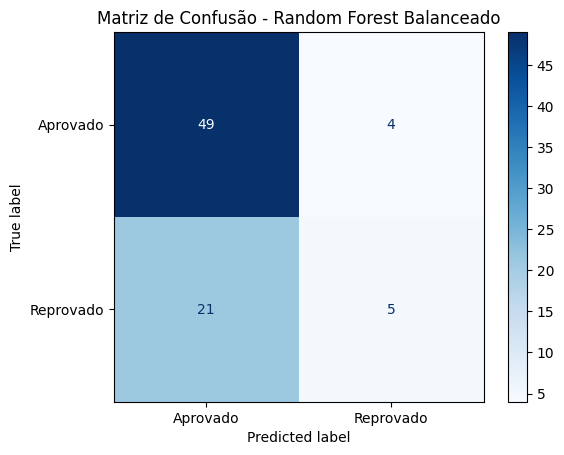

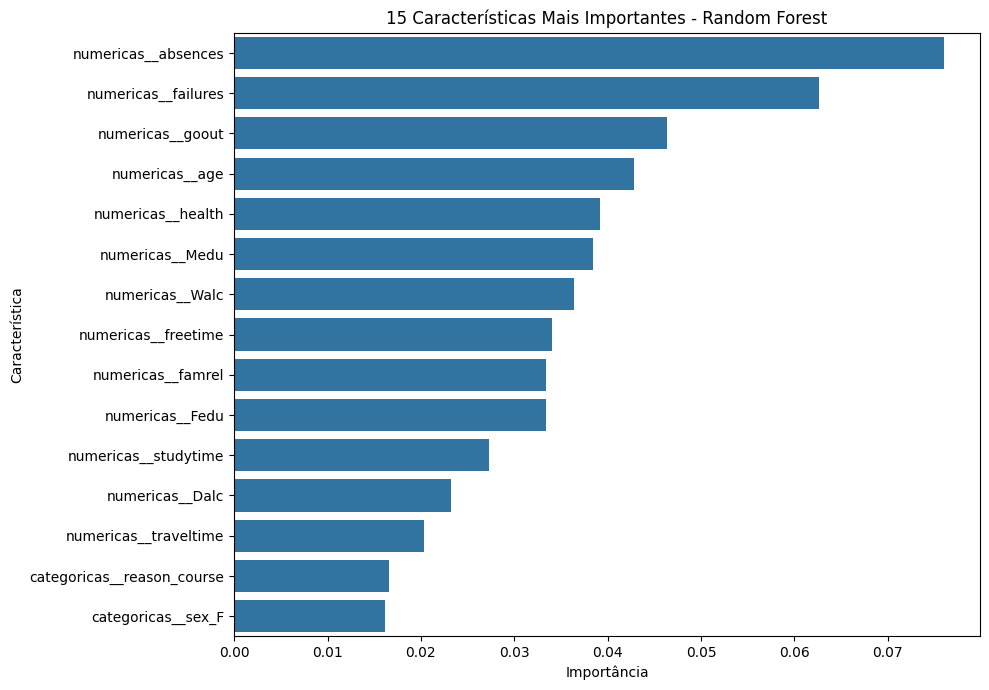

In [46]:
modelo_rf_balanceado = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

modelo_rf_balanceado.fit(X_train, y_train)
y_pred_rf_bal = modelo_rf_balanceado.predict(X_test)

acuracia_rf_bal = accuracy_score(y_test, y_pred_rf_bal)

print(f"Acurácia Random Forest Balanceado: {acuracia_rf_bal * 100:.2f}%")

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_rf_bal))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_bal,
    cmap="Blues"
)

plt.title("Matriz de Confusão - Random Forest Balanceado")
plt.show()

preprocessamento = modelo_rf.named_steps["preprocessamento"]

nomes_features = preprocessamento.get_feature_names_out()

nomes_features[:20]

importancias = modelo_rf.named_steps["modelo"].feature_importances_

import pandas as pd

df_importancias = pd.DataFrame({
    "Caracteristica": nomes_features,
    "Importancia": importancias
})

df_importancias = df_importancias.sort_values(
    "Importancia",
    ascending=False
)

df_importancias.head(15)

top15 = df_importancias.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top15,
    x="Importancia",
    y="Caracteristica"
)

plt.title("15 Características Mais Importantes - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Característica")

plt.tight_layout()
plt.show()

Acurácia Random Forest com G1/G2: 91.14%

Relatório de Classificação:
              precision    recall  f1-score   support

    Aprovado       0.93      0.94      0.93        53
   Reprovado       0.88      0.85      0.86        26

    accuracy                           0.91        79
   macro avg       0.90      0.89      0.90        79
weighted avg       0.91      0.91      0.91        79



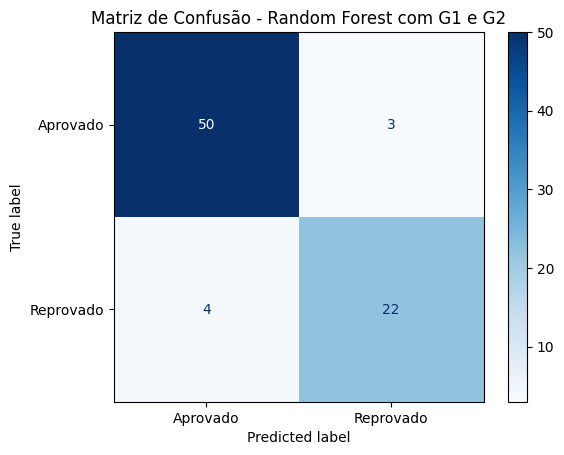

In [57]:
X_com_notas = df.drop(columns=["G3", "resultado"])

y_com_notas = df["resultado"]

X_train_notas, X_test_notas, y_train_notas, y_test_notas = train_test_split(
    X_com_notas,
    y_com_notas,
    test_size=0.20,
    random_state=42,
    stratify=y_com_notas
)
categoricas_notas = X_com_notas.select_dtypes(
    include=["object"]
).columns

numericas_notas = X_com_notas.select_dtypes(
    include=["int64", "float64"]
).columns

preprocessador_notas = ColumnTransformer(
    transformers=[
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            categoricas_notas
        ),
        (
            "numericas",
            StandardScaler(),
            numericas_notas
        )
    ]
)
modelo_rf_notas = Pipeline([
    ("preprocessamento", preprocessador_notas),
    ("modelo", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])
modelo_rf_notas.fit(
    X_train_notas,
    y_train_notas
)
y_pred_rf_notas = modelo_rf_notas.predict(
    X_test_notas
)
y_pred_rf_notas = modelo_rf_notas.predict(
    X_test_notas
)
acuracia_rf_notas = accuracy_score(
    y_test_notas,
    y_pred_rf_notas
)

print(
    f"Acurácia Random Forest com G1/G2: "
    f"{acuracia_rf_notas * 100:.2f}%"
)

print("\nRelatório de Classificação:")

print(
    classification_report(
        y_test_notas,
        y_pred_rf_notas
    )
)
ConfusionMatrixDisplay.from_predictions(
    y_test_notas,
    y_pred_rf_notas,
    cmap="Blues"
)

plt.title(
    "Matriz de Confusão - Random Forest com G1 e G2"
)

plt.show()

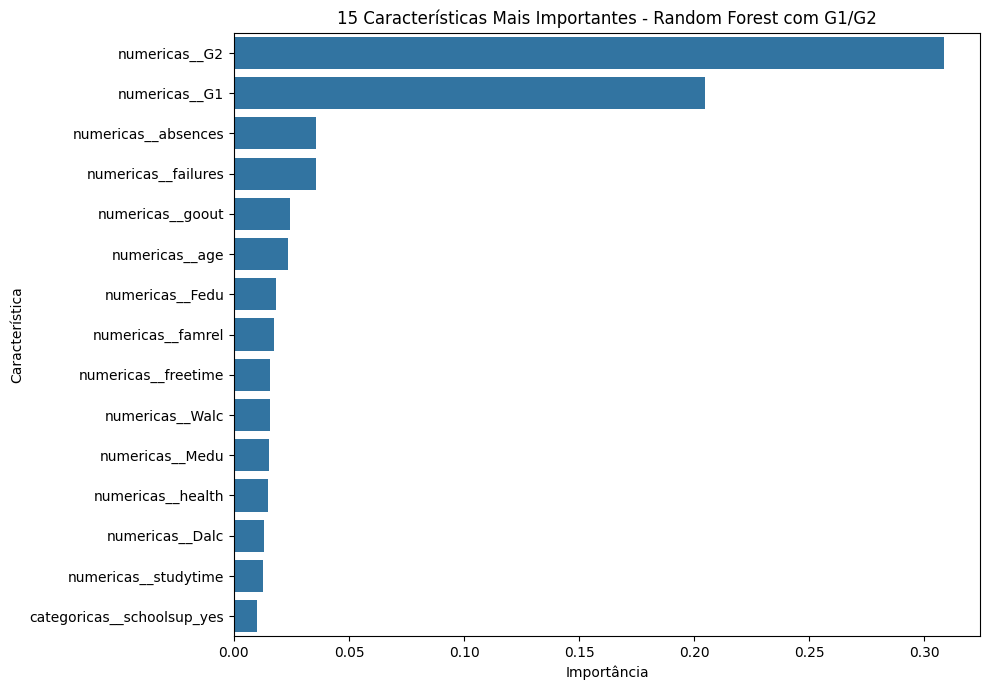

In [60]:
preprocessamento_notas = modelo_rf_notas.named_steps[
    "preprocessamento"
]

nomes_features_notas = (
    preprocessamento_notas.get_feature_names_out()
)

importancias_notas = (
    modelo_rf_notas.named_steps["modelo"].feature_importances_
)
df_importancias_notas = pd.DataFrame({
    "Caracteristica": nomes_features_notas,
    "Importancia": importancias_notas
})

df_importancias_notas = df_importancias_notas.sort_values(
    "Importancia",
    ascending=False
)

df_importancias_notas.head(15)
top15_notas = df_importancias_notas.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top15_notas,
    x="Importancia",
    y="Caracteristica"
)

plt.title(
    "15 Características Mais Importantes - Random Forest com G1/G2"
)

plt.xlabel("Importância")
plt.ylabel("Característica")

plt.tight_layout()
plt.show()

Accuracy: 0.909 (± 0.033)
Precision: 0.896 (± 0.037)
Recall: 0.901 (± 0.043)
F1: 0.897 (± 0.039)
Recall Reprovado por fold:
[0.88461538 0.92307692 0.73076923 0.88461538 0.96153846]

Recall médio Reprovado: 0.877 (± 0.078)
['Aprovado' 'Reprovado']
ROC-AUC: 0.975


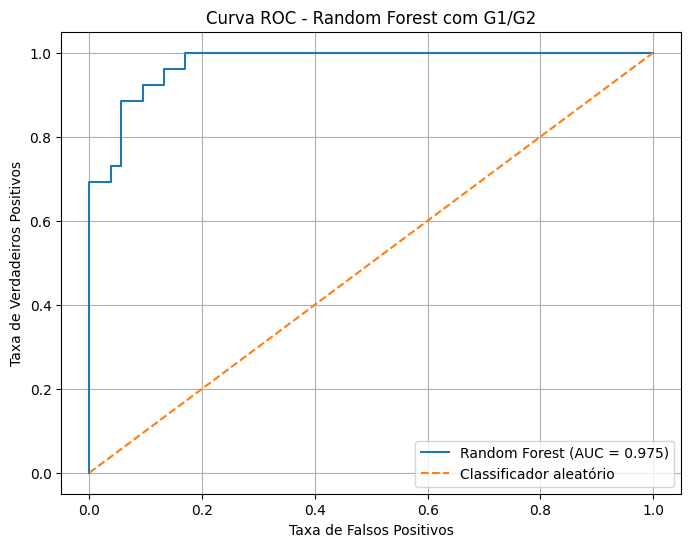

In [69]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
metricas = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}

resultado_cv = cross_validate(
    modelo_rf_notas,
    X_com_notas,
    y_com_notas,
    cv=cv,
    scoring=metricas
)
for metrica in metricas:
    valores = resultado_cv[f"test_{metrica}"]

    print(
        f"{metrica.capitalize()}: "
        f"{valores.mean():.3f} "
        f"(± {valores.std():.3f})"
    )
    from sklearn.metrics import make_scorer, recall_score

recall_reprovado = make_scorer(
    recall_score,
    pos_label="Reprovado"
)

resultado_recall = cross_validate(
    modelo_rf_notas,
    X_com_notas,
    y_com_notas,
    cv=cv,
    scoring={"recall_reprovado": recall_reprovado}
)

valores_recall = resultado_recall["test_recall_reprovado"]

print("Recall Reprovado por fold:")
print(valores_recall)

print(
    f"\nRecall médio Reprovado: "
    f"{valores_recall.mean():.3f} "
    f"(± {valores_recall.std():.3f})"
)
classes = modelo_rf_notas.named_steps["modelo"].classes_

print(classes)

indice_reprovado = list(classes).index("Reprovado")

y_prob_rf_notas = modelo_rf_notas.predict_proba(
    X_test_notas
)[:, indice_reprovado]
y_test_binario = (
    y_test_notas == "Reprovado"
).astype(int)
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_test_binario,
    y_prob_rf_notas
)

auc = roc_auc_score(
    y_test_binario,
    y_prob_rf_notas
)

print(f"ROC-AUC: {auc:.3f}")

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificador aleatório"
)

plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC - Random Forest com G1/G2")

plt.legend()
plt.grid()

plt.show()

In [70]:
def prever_estudante(dados_estudante):
    # Transforma os dados em DataFrame
    aluno = pd.DataFrame([dados_estudante])

    # Garante a mesma ordem das colunas usadas no treinamento
    aluno = aluno[X_com_notas.columns]

    # Faz a previsão
    previsao = modelo_rf_notas.predict(aluno)[0]

    # Obtém as probabilidades
    probabilidades = modelo_rf_notas.predict_proba(aluno)[0]

    # Classes do modelo
    classes = modelo_rf_notas.named_steps["modelo"].classes_

    print("=" * 40)
    print("PREVISÃO DE DESEMPENHO DO ESTUDANTE")
    print("=" * 40)

    print(f"\nResultado previsto: {previsao}")

    print("\nProbabilidades:")

    for classe, probabilidade in zip(classes, probabilidades):
        print(f"{classe}: {probabilidade * 100:.2f}%")

In [73]:
aluno_teste = X_test_notas.iloc[0].to_dict()

aluno_teste

prever_estudante(aluno_teste)

print(
    "Resultado real:",
    y_test_notas.iloc[0]
)

PREVISÃO DE DESEMPENHO DO ESTUDANTE

Resultado previsto: Reprovado

Probabilidades:
Aprovado: 18.00%
Reprovado: 82.00%
Resultado real: Reprovado


In [74]:
print("DADOS PRINCIPAIS DO ESTUDANTE")
print("-" * 35)

print("Idade:", aluno_teste["age"])
print("Tempo de estudo:", aluno_teste["studytime"])
print("Reprovações anteriores:", aluno_teste["failures"])
print("Faltas:", aluno_teste["absences"])
print("G1:", aluno_teste["G1"])
print("G2:", aluno_teste["G2"])

print()

prever_estudante(aluno_teste)

print(
    "\nResultado real:",
    y_test_notas.iloc[0]
)

DADOS PRINCIPAIS DO ESTUDANTE
-----------------------------------
Idade: 19
Tempo de estudo: 1
Reprovações anteriores: 1
Faltas: 0
G1: 6
G2: 5

PREVISÃO DE DESEMPENHO DO ESTUDANTE

Resultado previsto: Reprovado

Probabilidades:
Aprovado: 18.00%
Reprovado: 82.00%

Resultado real: Reprovado


In [79]:
aluno_novo = X_test_notas.iloc[0].copy()

aluno_novo["age"] = 17
aluno_novo["studytime"] = 3
aluno_novo["failures"] = 0
aluno_novo["absences"] = 2

aluno_novo["G1"] = 14
aluno_novo["G2"] = 15

prever_estudante(
    aluno_novo.to_dict()
)
aluno_novo_2 = X_test_notas.iloc[0].copy()

aluno_novo_2["age"] = 17
aluno_novo_2["studytime"] = 1
aluno_novo_2["failures"] = 2
aluno_novo_2["absences"] = 18

aluno_novo_2["G1"] = 7
aluno_novo_2["G2"] = 6

prever_estudante(
    aluno_novo_2.to_dict()
)

PREVISÃO DE DESEMPENHO DO ESTUDANTE

Resultado previsto: Aprovado

Probabilidades:
Aprovado: 95.50%
Reprovado: 4.50%
PREVISÃO DE DESEMPENHO DO ESTUDANTE

Resultado previsto: Reprovado

Probabilidades:
Aprovado: 22.50%
Reprovado: 77.50%


In [80]:
import joblib

joblib.dump(
    modelo_rf_notas,
    "modelo_student_performance.pkl"
)

['modelo_student_performance.pkl']

In [82]:
from google.colab import files

files.download(
    "modelo_student_performance.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [85]:
import joblib

modelo_carregado = joblib.load(
    "modelo_student_performance.pkl"
)

In [86]:
modelo_carregado.predict(
    X_test_notas.iloc[[0]]
)

array(['Reprovado'], dtype=object)